In [2]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Subset
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

dataset: https://data.caltech.edu/records/mzrjq-6wc02

# Task 1: CNN Classification
## Part 1

In [4]:
# Transform image to be 128 by 128
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    # Need to convert images to RGB
    transforms.Lambda(lambda image: image.convert('RGB')),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

# Load dataset
dataset = datasets.Caltech101(
    root="./data",
    download=True,
    transform=transform
)

num_classes = len(dataset.categories)
print('num classes:', num_classes)

# Train/Validation split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)

100%|██████████| 137M/137M [00:08<00:00, 16.3MB/s]


num classes: 101


In [5]:
# Pytorch CNN
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 128x128
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64x64

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32x32

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16x16
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [6]:
# training function
def train(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

# evaluation function
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [7]:
# Training and evaluation loops
epochs = 10

for epoch in range(epochs):
    loss = train(model, train_loader)
    acc = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Val Acc={acc:.2f}%")

Epoch 1: Loss=3.4098, Val Acc=38.65%
Epoch 2: Loss=2.4892, Val Acc=51.73%
Epoch 3: Loss=1.9149, Val Acc=56.22%
Epoch 4: Loss=1.5071, Val Acc=59.16%
Epoch 5: Loss=1.1302, Val Acc=62.38%
Epoch 6: Loss=0.8421, Val Acc=63.48%
Epoch 7: Loss=0.6448, Val Acc=62.04%
Epoch 8: Loss=0.5023, Val Acc=63.36%
Epoch 9: Loss=0.4469, Val Acc=63.36%
Epoch 10: Loss=0.3687, Val Acc=62.67%


In [8]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.85      0.94      0.89        77
           1       0.94      0.97      0.96        78
           2       0.88      1.00      0.94        44
           3       0.97      0.99      0.98       152
           4       0.79      0.73      0.76        15
           5       0.91      1.00      0.95       153
           6       0.38      0.45      0.42        11
           7       0.00      0.00      0.00         5
           8       0.20      0.11      0.14         9
           9       0.17      0.33      0.22         6
          10       0.00      0.00      0.00         8
          11       1.00      0.25      0.40         8
          12       0.44      0.58      0.50        19
          13       0.55      0.50      0.52        22
          14       0.40      0.33      0.36        12
          15       0.62      0.76      0.68        17
          16       0.47      0.35      0.40        20
          17       0.30    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The CNN was designed with 3 convolution blocks with increasing channel size in order to capture more complex features. Each convolution is followed by a max pooling in order to reduce dimension and cost. A fully connected layer is then used to connect the extracted features to the 101 class predictions. Dropout was chosen in order to reduce overfitting due to class imbalances in the dataset. This model is evaluated mainly on accuracy (for validation during training) but also is evaluated on precision, recall, and f1-score. The accuracy for this model was a modest 65% due to the number of classes, their imbalances, and relatively small size of the dataset.

## Part 2


In [11]:

model = models.resnet50(pretrained=True)

# Freeze backbone because we have a small dataset
for param in model.parameters():
    param.requires_grad = False

# Replace final classification layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Only train final layer
for param in model.fc.parameters():
    param.requires_grad = True

# Setup model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 154MB/s]


In [12]:
# Training and evaluation loop
def train(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return 100 * correct / total


In [13]:
# Train resnet
epochs = 5

for epoch in range(epochs):
    loss = train(model, train_loader)
    acc = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Val Acc={acc:.2f}%")

Epoch 1: Loss=1.2957, Val Acc=86.35%
Epoch 2: Loss=0.3545, Val Acc=87.56%
Epoch 3: Loss=0.2505, Val Acc=87.67%
Epoch 4: Loss=0.1815, Val Acc=87.73%
Epoch 5: Loss=0.1374, Val Acc=87.38%


In [14]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.97      0.92      0.95        78
           1       0.91      0.98      0.94        83
           2       1.00      1.00      1.00        41
           3       0.99      0.98      0.99       170
           4       1.00      0.77      0.87        13
           5       0.91      0.98      0.95       160
           6       0.36      0.62      0.45         8
           7       0.75      0.50      0.60         6
           8       0.92      1.00      0.96        11
           9       0.62      0.93      0.74        14
          10       0.56      0.83      0.67         6
          11       1.00      0.50      0.67         6
          12       1.00      0.85      0.92        27
          13       1.00      0.90      0.95        20
          14       1.00      0.90      0.95        10
          15       1.00      0.83      0.91        12
          16       0.94      0.62      0.75        24
          17       0.88    

I chose to use resnet-50 as my model for transfer learning. Resnet-50 originally has 1000 output classes and therefore I needed to change the final fully connected layer from having an output of 1000 classes to have an output of 101 instead. This model performed significantly better than my custom CNN from pytorch. To train the model I froze the convolution parameters and only trained the fully connected layer as that is better for smaller datasets like caltech-101. It makes sense that this model performs better as Resnet-50 has 50 convolutional layers (compared to our 3) and was built to handle far more complex datasets and tasks. In contrast, my model was built with a performance to computation tradeoff to allow the model to be trained and developed within a timely fashion while still achieveing respectable results.

## Part 3

In [31]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Lambda(lambda image: image.convert('RGB')),

    # Data augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Lambda(lambda image: image.convert('RGB')),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [32]:
# Load dataset again
train_full = datasets.Caltech101(
    root="./data",
    download=True,
    transform=train_transform
)

val_full = datasets.Caltech101(
    root="./data",
    download=True,
    transform=val_transform
)

indices = np.arange(len(train_full))
np.random.shuffle(indices)

split = int(0.8 * len(indices))

train_idx = indices[:split]
val_idx = indices[split:]

train_data = Subset(train_full, train_idx)
val_data   = Subset(val_full, val_idx)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)

In [33]:
# Pytorch CNN
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 128x128
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64x64

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32x32

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16x16
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [34]:
# training function
def train(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

# evaluation function
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [35]:
# Training and evaluation loops
epochs = 10

for epoch in range(epochs):
    loss = train(model, train_loader)
    acc = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Val Acc={acc:.2f}%")

Epoch 1: Loss=3.7639, Val Acc=33.64%
Epoch 2: Loss=3.1771, Val Acc=41.30%
Epoch 3: Loss=2.8667, Val Acc=45.85%
Epoch 4: Loss=2.6528, Val Acc=48.39%
Epoch 5: Loss=2.4695, Val Acc=53.86%
Epoch 6: Loss=2.3291, Val Acc=54.09%
Epoch 7: Loss=2.2017, Val Acc=56.85%
Epoch 8: Loss=2.1161, Val Acc=57.95%
Epoch 9: Loss=2.0206, Val Acc=58.29%
Epoch 10: Loss=1.9612, Val Acc=59.45%


In [36]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96       104
           1       0.98      0.99      0.99       103
           2       0.48      1.00      0.65        42
           3       0.88      0.99      0.94       162
           4       0.67      0.40      0.50        10
           5       0.84      0.99      0.91       160
           6       0.00      0.00      0.00         7
           7       0.00      0.00      0.00        10
           8       0.33      0.14      0.20         7
           9       0.17      0.29      0.21         7
          10       0.25      0.10      0.14        10
          11       0.44      0.67      0.53         6
          12       0.67      0.89      0.76        18
          13       0.33      0.33      0.33        18
          14       0.33      0.20      0.25         5
          15       0.42      0.36      0.39        22
          16       0.47      0.33      0.39        21
          17       0.46    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


My model performed worse after data augmentation. This makes sense as the model is learning a harder less clean (more realistic) set of images. So while the training accuracy goes down, the model will be able to generalize to patterns easier with more messy images that may not be aligned for example. For this messier data it is harder for the model to memorize and therefore likely woudld need a higher learning rate or more epochs to equal the validation performance of the model trained on non augmented data.

# Task 2: Generating images with models
## Part 1
Dataset: https://cs.stanford.edu/~acoates/stl10/

In [64]:
# Get images
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

dataset = datasets.STL10(root='./data', split='unlabeled', download=True, transform=transform)

dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [69]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()

        # Encoder
        self.enc = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),   # 64 -> 32
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # 32 -> 16
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), # 16 -> 8
            nn.ReLU()
        )

        # Updated input size for linear layers to match 128x128 input images
        self.fc_mu = nn.Linear(128 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(128 * 8 * 8, latent_dim)

        # Decoder
        self.fc_decode = nn.Linear(latent_dim, 128 * 8 * 8)

        self.dec = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 8 -> 16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   # 16 -> 32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),    # 32 -> 64
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.enc(x)
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, 128, 8, 8)
        return self.dec(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def loss_function(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl

In [74]:
# Training Loop

model = VAE(latent_dim=128).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, _ in dataloader:
        x = x.to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(x)

        loss = loss_function(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(dataset):.4f}")

Epoch 1, Loss: 299.9658
Epoch 2, Loss: 239.3483
Epoch 3, Loss: 232.9346
Epoch 4, Loss: 229.7121
Epoch 5, Loss: 227.7012


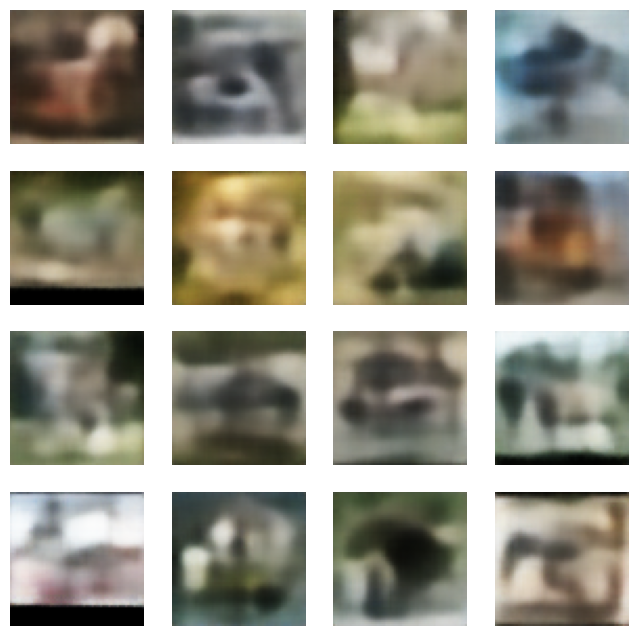

In [77]:
# Display Generated images
model.eval()

with torch.no_grad():
    z = torch.randn(16, 128).to(device)
    samples = model.decode(z).cpu()

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i].permute(1, 2, 0))
    ax.axis("off")

plt.show()

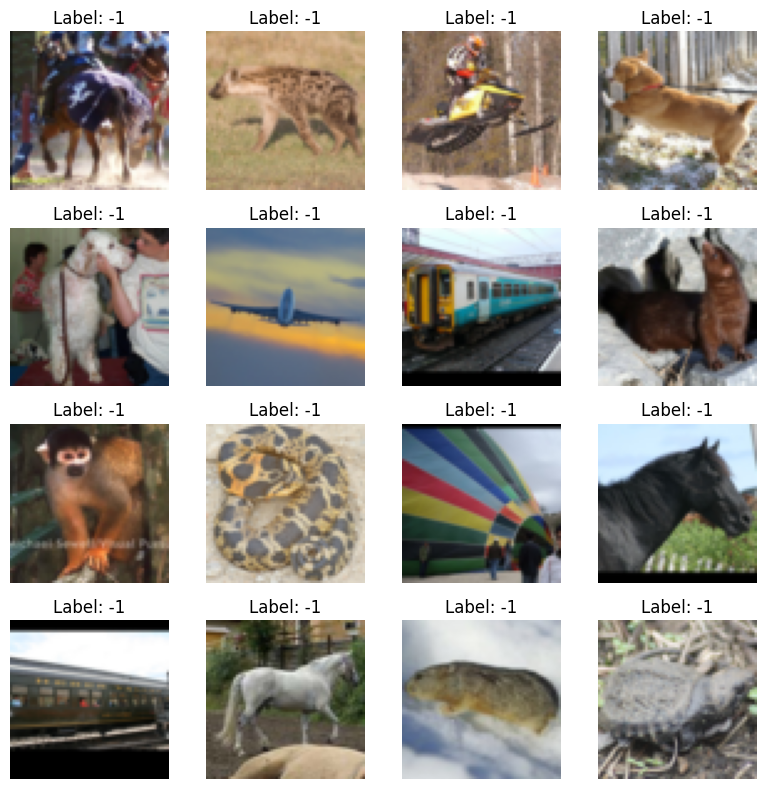

In [78]:
images, labels = next(iter(dataloader))

# -----------------------
# Plot images
# -----------------------
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0)  # CHW → HWC
    ax.imshow(img)
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Part 2

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# params for models
batch_size = 64
image_size = 128
nz = 100        # latent vector size
ngf = 64        # generator feature maps
ndf = 64        # discriminator feature maps
num_epochs = 10
lr = 0.0002
beta1 = 0.5

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

# Dataset load
dataset = datasets.STL10(root='./data', split='unlabeled', download=True, transform=transform)

dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [20]:
# Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # input: Z → (nz,1,1)
            nn.ConvTranspose2d(nz, ngf*16, 4, 1, 0),   # 4x4
            nn.BatchNorm2d(ngf*16),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*16, ngf*8, 4, 2, 1), # 8x8
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1),  # 16x16
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1),  # 32x32
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1),    # 64x64
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, 3, 4, 2, 1),        # 128x128
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # input: 3x128x128
            nn.Conv2d(3, ndf, 4, 2, 1),     # 64x64
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf*2, 4, 2, 1), # 32x32
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1), # 16x16
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1), # 8x8
            nn.BatchNorm2d(ndf*8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*8, ndf*16, 4, 2, 1), # 4x4
            nn.BatchNorm2d(ndf*16),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*16, 1, 4, 1, 0),    # 1x1
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(-1)

# Model initialization
netG = Generator().to(device)
netD = Discriminator().to(device)

criterion = nn.BCELoss()

optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

In [21]:
# Train loop
for epoch in range(num_epochs):
    for i, (real_images, _) in enumerate(dataloader):
        real_images = real_images.to(device)
        b_size = real_images.size(0)

        # Labels
        real_labels = torch.ones(b_size, device=device)
        fake_labels = torch.zeros(b_size, device=device)

        # Discriminator training
        netD.zero_grad()

        output_real = netD(real_images)
        loss_real = criterion(output_real, real_labels)

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_images = netG(noise)

        output_fake = netD(fake_images.detach())
        loss_fake = criterion(output_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizerD.step()

        #Generator training
        netG.zero_grad()

        output_fake = netD(fake_images)
        loss_G = criterion(output_fake, real_labels)

        loss_G.backward()
        optimizerG.step()

        if i % 100 == 0:
            print(f"Epoch [{epoch}/{num_epochs}] Step {i} "
                  f"Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")

Epoch [0/10] Step 0 Loss D: 1.4365, Loss G: 5.0525
Epoch [0/10] Step 100 Loss D: 0.6929, Loss G: 5.0878
Epoch [0/10] Step 200 Loss D: 2.7129, Loss G: 3.2425
Epoch [0/10] Step 300 Loss D: 2.8756, Loss G: 2.7851
Epoch [0/10] Step 400 Loss D: 0.6001, Loss G: 2.2934
Epoch [0/10] Step 500 Loss D: 0.8046, Loss G: 1.3288
Epoch [0/10] Step 600 Loss D: 0.8186, Loss G: 3.0407
Epoch [0/10] Step 700 Loss D: 1.0274, Loss G: 1.9289
Epoch [0/10] Step 800 Loss D: 0.8545, Loss G: 2.4731
Epoch [0/10] Step 900 Loss D: 0.8269, Loss G: 3.3628
Epoch [0/10] Step 1000 Loss D: 1.0619, Loss G: 1.3428
Epoch [0/10] Step 1100 Loss D: 0.6412, Loss G: 2.9819
Epoch [0/10] Step 1200 Loss D: 1.2078, Loss G: 2.2942
Epoch [0/10] Step 1300 Loss D: 0.4924, Loss G: 3.7975
Epoch [0/10] Step 1400 Loss D: 0.8765, Loss G: 2.1180
Epoch [0/10] Step 1500 Loss D: 0.8183, Loss G: 2.5899
Epoch [1/10] Step 0 Loss D: 0.5798, Loss G: 2.6598
Epoch [1/10] Step 100 Loss D: 1.6936, Loss G: 7.5738
Epoch [1/10] Step 200 Loss D: 0.9399, Loss G

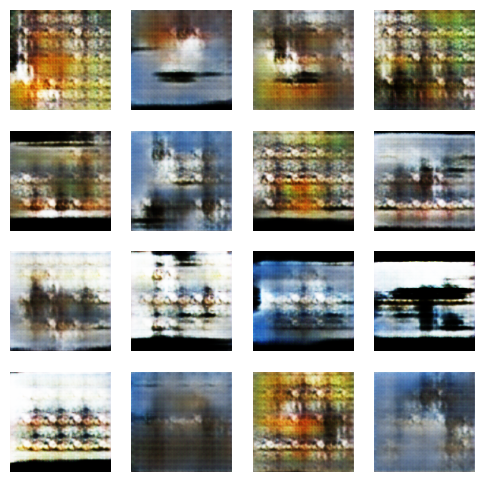

In [18]:
# Generate images
netG.eval()
with torch.no_grad():
    noise = torch.randn(16, nz, 1, 1, device=device)
    fake_images = netG(noise).cpu()

# Plot
fig, axes = plt.subplots(4, 4, figsize=(6,6))
for i, ax in enumerate(axes.flat):
    img = (fake_images[i] + 1) / 2  # [-1,1] → [0,1]
    ax.imshow(img.permute(1,2,0))
    ax.axis("off")

plt.show()

# Task 3: NLP and Attention Mechanism
In Hw5_task3 notebook in order to not undo other work as had to reset environment multiple times.